In [ ]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import warpSPHCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import warpSPHCore as sph
from warpSPHCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from warpSPHIntegrators.integration import *
from warpSPHCore import *

# This library
from warpSPH import *
from warpSPH.modules.timestep.compressible import computeTimestep

# The case utilities that contain all the case setup functions for the various test cases
from warpSPH.caseUtils import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


# Sedov-Taylor Blastwave (1D)

This notebook runs the 1D Sedov-Taylor blastwave benchmark in the compressible SPH suite.

The case deposits localized energy into a near-rest medium to generate a self-similar blastwave, testing strong-shock propagation and energy consistency.

This notebook follows the same reusable structure used across all 15 compressible benchmark cases:

1. Configure imports and numeric precision.
2. Define case-specific physical parameters and initial-condition data.
3. Build domain, solver, and scheme configuration from shared builders.
4. Sample and initialize particles/state for the selected case.
5. Run the time integration loop with diagnostics and adaptive timestep control.
6. Export trajectory/state snapshots and generate image frames during the run.
7. Finalize outputs by writing final state data and rendering media artifacts (for example MP4/GIF).

Precision note: switching between single and double precision is controlled in the import/configuration block. Because precision is set when core modules/kernels are initialized, any precision change requires a kernel restart before re-running the notebook.

![](outputs/06-Sedov_Taylor_Blastwave_1D.gif)

In [ ]:
nx = 800
dim = 1
L = 2
n_h = 4

goalRadius = 0.8
gamma = 5/3
rho0 = 1
E0 = 1

extraData = {
    'nx': nx,
    'dim': dim,
    'L': L,
    'n_h': n_h,

    'gamma': gamma,
    'rho0': rho0,
    'goalRadius': goalRadius,
}

In [3]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()

config, integrator = buildConfig(
    domain = buildDomainDescription(L, dim, True, device, dtype),
    dim = dim,
    kernel = KernelFunctions.B7,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.KernelMeanSymmetric,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = None,
    adaptiveDt = True,
    cflFactor=0.3,
)
config.nx = nx

config.minDt = 1e-8
# config.dx = L / (nx * 2)

scheme = CompressibleSPHScheme.CRKSPH
SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(scheme)


schemeConfig = SimulationConfig()
schemeConfig.gamma = gamma
schemeConfig.rho0 = rho0


schemeConfig.viscositySwitchParams.scheme = ViscositySwitch.NoneSwitch
schemeConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen
schemeConfig.adaptiveSupportCorrections = False


In [4]:
from warpSPH.caseUtils.sedov import *

In [10]:
compressibleSystem = buildSedov(
    SimulationSystem, SimulationState, 
    config = config,
    nx = nx, dim = dim, domainExtent = L, 
    periodicDomain = True, 
    rho0 = rho0, E0 = E0, 
    initialization = 'hat', 
    gamma = gamma, kernel = config.kernel, 
    targetNeighbors = config.targetNeighbors, 
    dtype = config.dtype, device = config.device)

In [11]:
from warpSPH.caseUtils.sedov.sedovSolution import SedovSolution, radius, beta
from scipy.optimize import minimize

answer = SedovSolution(
    nDim = dim,
    gamma = gamma,
    rho0 = rho0,
    E0 = E0,
    h0 = 2/nx
)
nu1 = 1.0/(answer.nu + 2.0)
nu2 = 2.0*nu1
goalTime = (goalRadius*(answer.alpha*rho0/E0)**nu1)**(1.0/nu2)
vs, r2, v2, rho2, P2 = answer.shockState(goalTime)
rad_t = lambda t: radius(beta(dim), E0, t, rho0, 1)

targetTime = minimize(lambda t: (rad_t(t) - goalRadius) ** 2, 0.2).x[0]

print(f'Target Time [paper]: {targetTime:8.4g}, {rad_t(targetTime):8.4g} / {answer.shockState(targetTime)[1]:8.4g}')
print(f'Target Time  [code]: {goalTime:8.4g}, {rad_t(goalTime):8.4g} / {answer.shockState(goalTime)[1]:8.4g}')

Target Time [paper]:   0.6119,      0.8 /   0.8531
Target Time  [code]:   0.5556,   0.7502 /      0.8


In [12]:


def setupPlot(axis, t):
    vs, r2, v2, rho2, P2 = answer.shockState(t)
    rt = rad_t(t)
    
    for ax in axis.flatten():
        ax.axvline(r2, color = 'black', linestyle = '--', alpha = 0.25)
        ax.axvline(-r2, color = 'black', linestyle = '--', alpha = 0.25)
        ax.axvline(rt, color = 'red', linestyle = '--', alpha = 0.25)
        ax.axvline(-rt, color = 'red', linestyle = '--', alpha = 0.25)
        
        
    # axis[1,0].axhline(vt, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(vs, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(-vs, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(v2, color = 'red', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(-v2, color = 'red', linestyle = '--', alpha = 0.25)
    axis[0,1].axhline(rho0, color = 'black', linestyle = '--', alpha = 0.25)
    axis[0,1].axhline(rho2, color = 'black', linestyle = '--', alpha = 0.25)

    axis[0,0].set_xlim(0, 1)
    axis[0,1].set_xlim(0, 1)
    axis[1,0].set_xlim(0, 1)
    axis[1,1].set_xlim(0, 1)

    axis[0,0].set_ylim(1e-18, 30)
    axis[0,1].set_ylim(0.1, rho2*1.1)
    axis[1,0].set_ylim(0, vs)

    axis[0,0].set_yscale('log')
    axis[0,1].set_yscale('log')

def plotState(fig, axis, state):

    axis[0,0].scatter(state.state.positions.cpu().numpy(), state.state.internalEnergies.cpu().numpy(), s = state.state.supports.cpu().numpy() * 100)
    axis[0,1].scatter(state.state.positions.cpu().numpy(), state.state.densities.cpu().numpy(), s = state.state.supports.cpu().numpy() * 100)
    axis[1,0].scatter(state.state.positions.cpu().numpy(), state.state.velocities.cpu().numpy(), s = state.state.supports.cpu().numpy() * 100)
    axis[1,1].scatter(state.state.positions.cpu().numpy(), state.state.supports.cpu().numpy(), s = state.state.supports.cpu().numpy() * 100)

    axis[0,0].set_title('Internal Energy')
    axis[0,1].set_title('Density')
    axis[1,0].set_title('Velocity')
    axis[1,1].set_title('Support')

    kineticEnergy = 0.5 * (torch.linalg.norm(state.state.velocities, dim = -1) **2 * state.state.masses).sum()
    thermalEnergy = (state.state.internalEnergies * state.state.masses).sum()
    totalEnergy = kineticEnergy + thermalEnergy

    fig.suptitle(f'\nSedov-Taylor Explosion, t = {state.t:2f}, dt = {config.dt:.3g}, ptcls = {len(state.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')
    fig.tight_layout()

    # prefix = './images/sedov_1d_201_sharp/'
    # os.makedirs(prefix, exist_ok = True)

    rt = rad_t(state.t)
    # vt = vel_t(state.t)
        
    t = state.t.cpu() if isinstance(state.t, torch.Tensor) else state.t
    setupPlot(axis, t)


In [13]:
runningState = compressibleSystem.initializeNewState()

kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
totalEnergy = kineticEnergy + thermalEnergy

In [14]:
caseName = '06-Sedov_Taylor_Blastwave_1D'
exportPath = prepExport(f'{caseName}', config, schemeConfig, scheme, export_fn)
exportSimulationSystem(exportPath, 'initialState', scheme, compressibleSystem, exportAdjacency = False, stages = None, exportStagesAdjacency = False, extraData = dict({
    'kineticEnergy': kineticEnergy,
    'thermalEnergy': thermalEnergy,
    'totalEnergy': totalEnergy,
    'frame_num': 0,
}, **extraData))


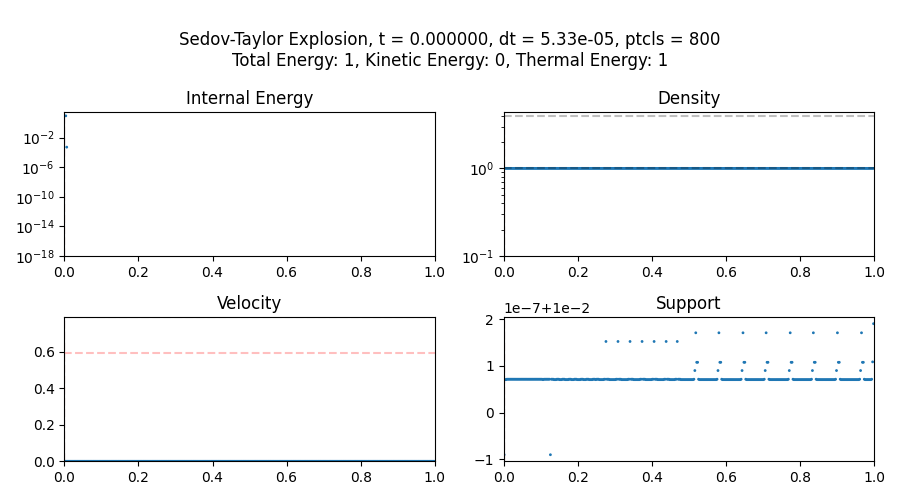

In [15]:
fig, axis = plt.subplots(2,2, figsize = (9, 5), squeeze = False)

plotState(fig, axis, runningState)

fig.tight_layout()

imagePath = f'{exportPath}/images'
os.makedirs(imagePath, exist_ok = True)
fig.savefig(f'{imagePath}/frame_{0:05d}.png')


In [16]:
# config.dt = 1e-4
t_limit = goalTime
nSteps = int(t_limit / config.dt)

print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 20

runningState = compressibleSystem.initializeNewState()

trajectory = []

priorStep = None
for i in (tq := tqdm(range(nSteps), leave = True)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        compParams = schemeConfig,
        verbose = False,
        # priorStep = priorStep
    )
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state
    kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
    thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
    totalEnergy = kineticEnergy + thermalEnergy

    trajectory.append(
        (i, (i+1)*config.dt, totalEnergy.item(), kineticEnergy.item(), thermalEnergy.item(), timing)
,     )

    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g}, TE: {totalEnergy:.3g}, KE: {kineticEnergy:.3g}, IE: {thermalEnergy:.3g}")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break
    if i % 50 == 0:
        axis[0,0].cla()
        axis[0,1].cla()
        axis[1,0].cla()
        axis[1,1].cla()
        plotState(fig, axis, runningState)
        # fig.tight_layout()
        fig.canvas.draw()
        fig.canvas.flush_events()
        fig.savefig(f'{imagePath}/frame_{i:05d}.png')
        
    if i % 500 == 0:
        exportSimulationSystem(exportPath, f'state_{i:04d}', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
            'kineticEnergy': kineticEnergy,
            'thermalEnergy': thermalEnergy,
            'totalEnergy': totalEnergy,
            'frame_num': i,
        }))
        

Running with dt: 5.325958409230225e-05, which gives nSteps: 10432


  0%|          | 0/10432 [00:00<?, ?it/s]

Module compressibleSPH.modules.adaptiveSupport.wp_psi 8875fe6 load on device 'cuda:0' took 4.96 ms  (cached)
Module compressibleSPH.modules.adaptiveSupport.wp_psi0 0564b5b load on device 'cuda:0' took 6.86 ms  (cached)
Module warpSPHCore.crk.crk_volume a999eca load on device 'cuda:0' took 7.85 ms  (cached)
Module warpSPHCore.crk.crk_moments eedc208 load on device 'cuda:0' took 10.19 ms  (cached)
Module warpSPHCore.crk.crk_density c8e8d13 load on device 'cuda:0' took 6.36 ms  (cached)
Module warpSPHCore.operations.wp_gradient 5b109d2 load on device 'cuda:0' took 9.47 ms  (cached)
Module compressibleSPH.modules.crk.accel 7ac821f load on device 'cuda:0' took 7.81 ms  (cached)
Module compressibleSPH.modules.crk.dudt 28189e6 load on device 'cuda:0' took 7.42 ms  (cached)
Module compressibleSPH.modules.compSPH.balance 1010fc2 load on device 'cuda:0' took 6.43 ms  (cached)


In [17]:
exportSimulationSystem(exportPath, f'finalState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
    'kineticEnergy': kineticEnergy,
    'thermalEnergy': thermalEnergy,
    'totalEnergy': totalEnergy,
    'frame_num': i,
}))

In [18]:
ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 50 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# now copy the output.mp4 and out.gif to the parent directory for easier access
shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');